# Fitting a Bayesian Neural Network Regression model using HMC

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import math
import torch
import torch.nn as nn
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In Lecture 35, we discussed, as an application of HMC, Bayesian inference for neural network regression. We will revisit this analysis in this Lab, and go into some deeper analysis that was done in Lecture 35. 

Given a response variable $y$ and covariate vector $x = (x_1, \dots, x_d)$, the two-hidden layer  neural network model is given by: 
\begin{align*}
    y = f_{\theta}(x) + \epsilon
\end{align*}
where $f_{\theta}(x)$ is: 
\begin{align*}
   f_{\theta}(x) = W_3^T \sigma \left( W_2^T \sigma(W_1^T x + b_1) + b_2 \right) + b_3
\end{align*}
The vector $\theta$ of parameters contains all the entries of $W_1, W_2, W_3, b_1, b_2, b_3$. This is a two-hidden layer network because the function $f_{\theta}(x)$ can be thought of as being constructed as: 
\begin{align*}
   x \overset{\text{layer 1}}{\rightarrow} h^{(1)} := \sigma(W_1^T x + b_1) \overset{\text{layer 2}}{\rightarrow} h^{(2)} := \sigma(W_2^T h^{(1)} + b_2) \overset{\text{output}}{\rightarrow} f_{\theta}(x) = W_3^T h^{(2)} + b_3. 
\end{align*}
$h^{(1)}$ and $h^{(2)}$ constitute the variables in the two hidden layers. 

Our goal is to apply this regression model to the diabetes dataset (this is a standard benchmark dataset for regression from the library scikitlearn). 

In [12]:
import pandas as pd
from sklearn.datasets import load_diabetes

data = load_diabetes()

X = data.data
y = data.target

df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

print(df.head())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


Here target will be our response variable $y$. This is a quantitative measure of diabetes progression measured one year after baseline. The other variables are all covariates. $s_1, \dots, s_6$ are numerical blood serum measurements: total cholestrol (s1), LDL (s2), HDL (s3), colesterol/HDL ratio (s4), log of triglycerides (s5) and blood sugar level (s6). 

Below we split the data into training and test datasets. 

In [13]:
seed = 123
X_train, X_test, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.25, random_state=seed)

Below we standardize the training data (and then apply the same standardization to the test data). 

In [14]:
x_scaler = StandardScaler()
X_train = x_scaler.fit_transform(X_train)
X_test = x_scaler.transform(X_test)

y_mean = y_train_raw.mean()
y_std = y_train_raw.std()

y_train = (y_train_raw - y_mean) / y_std
y_test = (y_test_raw - y_mean) / y_std

The standard approach for these kinds of regressions uses least squares estimation (along with a standard gradient based optimization method to minimize the least squares objective): 
\begin{align*}
   \hat{\theta} \in \text{argmin}  \frac{1}{n}\sum_{i=1}^n \left(y_i - f_{\theta}(x_i) \right)^2. 
\end{align*}
It is also common to include a ridge regularization penalty to the least squares objective: 
\begin{align*}
   \hat{\theta} \in \text{argmin}  \left[ \frac{1}{n}\sum_{i=1}^n \left(y_i - f_{\theta}(x_i) \right)^2 + \lambda \|\theta\|^2 \right]. 
\end{align*}
This ridge penalty is referred to as weight-decay in the machine learning literature. 

PyTorch is a standard library that contains functions for minimizing such objective functions. In order to apply PyTorch, we need to convert the data into tensors; this is done below. 

In [15]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

We shall fit a neural network with two hidden layers. The number of variables in each hidden layer is taken to be 20 (this is the length of the variables $h^{(1)}$ and $h^{(2)}$). 

In [16]:
print(X_train.shape[1])
layer_sizes = [X_train.shape[1], 20, 20, 1]

10


The total number of parameters in this neural network (i.e., the length of $\theta$) is calculated below. 

In [17]:
def num_params(layer_sizes):
    total = 0
    for din, dout in zip(layer_sizes[:-1], layer_sizes[1:]):
        total += din * dout + dout
    return total

D = num_params(layer_sizes)
print("Number of BNN parameters:", D)

Number of BNN parameters: 661


The number of parameters is 661. 

The following function converts a single long parameter vector $\theta$ to the weights and biases $W_i$ and $b_i$. 

In [18]:
def unpack_theta(theta, layer_sizes):
    """
    Converts a flat parameter vector theta into weight matrices and bias vectors.
    """
    params = []
    idx = 0
    for din, dout in zip(layer_sizes[:-1], layer_sizes[1:]):
        W = theta[idx: idx + din * dout].reshape(din, dout)
        idx += din * dout
        b = theta[idx: idx + dout].reshape(1, dout)
        idx += dout
        params.append((W, b))
    return params

The following gives the equation for the neural network model that we use. For the activation function $\sigma$, we shall use the tanh function. 

In [19]:
def bnn_forward(theta, X, layer_sizes):
    """
    Forward pass for fully connected tanh neural network.
    """
    params = unpack_theta(theta, layer_sizes)
    h = X
    for ell, (W, b) in enumerate(params):
        h = h @ W + b
        if ell < len(params) - 1:
            h = torch.tanh(h)
    return h

## Standard Approach: SGD to solve least squares with weight-decay

Before discussing Bayesian inference, let us first look at the standard approach for fitting neural network regression. This approach minimizes least squares (along with a possible weight-decay or ridge regularization) using gradient-based methods such as SGD. Below is the code for doing this. 

In [20]:
class SGDNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 1),
        )

    def forward(self, x):
        return self.net(x)


sgd_model = SGDNet(X_train.shape[1]).float()

criterion = nn.MSELoss()

weight_decay = 1e-1 #1e-1 seems to work well
optimizer = torch.optim.SGD(
    sgd_model.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=weight_decay,
)

n_epochs = 5000

for epoch in range(n_epochs):
    optimizer.zero_grad()

    pred = sgd_model(X_train_t)
    loss = criterion(pred, y_train_t)

    loss.backward()
    optimizer.step()

    if (epoch + 1) % 500 == 0:
        with torch.no_grad():
            test_pred = sgd_model(X_test_t)
            test_rmse = torch.sqrt(torch.mean((test_pred - y_test_t) ** 2)).item()
        print(
            f"SGD epoch {epoch+1:4d}, "
            f"train loss = {loss.item():.4f}, "
            f"test RMSE = {test_rmse:.4f}"
        )


with torch.no_grad():
    sgd_pred = sgd_model(X_test_t)

sgd_rmse_standardized = torch.sqrt(torch.mean((sgd_pred - y_test_t) ** 2)).item()
sgd_rmse_original = sgd_rmse_standardized * y_std

print("\nFrequentist NN via SGD")
print("Test RMSE, standardized scale:", sgd_rmse_standardized)
print("Test RMSE, original scale:", sgd_rmse_original)

SGD epoch  500, train loss = 0.4868, test RMSE = 0.7093
SGD epoch 1000, train loss = 0.4874, test RMSE = 0.7093
SGD epoch 1500, train loss = 0.4876, test RMSE = 0.7094
SGD epoch 2000, train loss = 0.4877, test RMSE = 0.7094
SGD epoch 2500, train loss = 0.4878, test RMSE = 0.7094
SGD epoch 3000, train loss = 0.4879, test RMSE = 0.7094
SGD epoch 3500, train loss = 0.4879, test RMSE = 0.7094
SGD epoch 4000, train loss = 0.4879, test RMSE = 0.7094
SGD epoch 4500, train loss = 0.4879, test RMSE = 0.7094
SGD epoch 5000, train loss = 0.4879, test RMSE = 0.7094

Frequentist NN via SGD
Test RMSE, standardized scale: 0.7094024419784546
Test RMSE, original scale: 54.58069829820268


After some trial and error, it can be discovered that a weight decay of 0.1 works well. Without weight decay, SGD run for 5000 epochs does not seem to work well (the test error seems to increase with iterations). The overall test error for this method is 54.58. 

### HMC for fitting this Bayesian Neural Network

In Lecture 35, we fit this model using a Bayesian approach and Hamiltonian Monte Carlo. For the prior, we use $N(0, \tau^2)$ for all the weights and biases. The posterior therefore (note that we are using, as usual, the $N(0, \sigma^2)$ prior on the errors): 
\begin{align*}
   \pi(\theta) \propto \exp \left[-\frac{1}{2 \sigma^2} \sum_{i=1}^n \left(y_i - f_{\theta}(x_i) \right)^2 - \frac{1}{2 \tau^2} \|\theta\|^2 \right]. 
\end{align*}
We assumed that $\sigma$ and $\tau$ are known (instead of placing priors on them). As a result, multiplicative terms only involving these parameters can be ignored as constants in the posterior above.  

We use HMC with the Hamiltonian given by $H(\theta, v) = -\log \pi(\theta) + 0.5 \|v\|^2$. The function $U(\theta) = -\log \pi(\theta)$ is called the potential energy. It is computed using the following code (note that $\pi(\theta)$ is our posterior). 

In [21]:
def potential_energy(theta):
    """
    U(theta) = negative log posterior up to an additive constant.
    Model:
        y_i | theta ~ N(f_theta(x_i), sigma^2)
    Prior:
        theta_j ~ N(0, tau^2), independently.
    """
    pred = bnn_forward(theta, X_train_t, layer_sizes)
    resid = y_train_t - pred
    neg_log_lik = 0.5 * torch.sum(resid ** 2) / sigma**2
    neg_log_prior = 0.5 * torch.sum(theta ** 2) / tau**2
    return neg_log_lik + neg_log_prior

To implement HMC, we would need to calculate gradients of $\log \pi(\theta)$. For this, we shall use PyTorch. 

In [22]:
def U_and_grad(theta):
    """
    Returns U(theta) and grad U(theta).
    """
    theta = theta.detach().clone().requires_grad_(True)
    U = potential_energy(theta)
    grad = torch.autograd.grad(U, theta)[0]
    return U.detach(), grad.detach()

The following is the main function for HMC. $\epsilon$ denotes the step size in leapfrog discretization, and $L$ denotes the number of leapfrog steps. 

In [23]:
def hmc_step(theta, epsilon, L):
    """
    One Hamiltonian Monte Carlo transition.

    Hamiltonian:
        H(theta, v) = U(theta) + 0.5 ||v||^2

    Momentum:
        v ~ N(0, I)
    """
    theta_current = theta.detach().clone()
    v_current = torch.randn_like(theta_current)

    current_U, current_grad = U_and_grad(theta_current)
    current_K = 0.5 * torch.sum(v_current ** 2)

    theta_new = theta_current.clone()
    v_new = v_current.clone()

    # First half momentum update
    v_new = v_new - 0.5 * epsilon * current_grad

    # Leapfrog integration
    for j in range(L):
        theta_new = theta_new + epsilon * v_new
        U_new, grad_new = U_and_grad(theta_new)
        if j != L - 1:
            v_new = v_new - epsilon * grad_new

    # Final half momentum update
    v_new = v_new - 0.5 * epsilon * grad_new

    # Momentum flip for reversibility
    v_new = -v_new

    proposed_U = U_new
    proposed_K = 0.5 * torch.sum(v_new ** 2)

    log_accept_ratio = (
        current_U + current_K - proposed_U - proposed_K
    )

    if torch.log(torch.rand(())) < log_accept_ratio:
        return theta_new.detach(), True, proposed_U.item()
    else:
        return theta_current.detach(), False, current_U.item()

Below we implement HMC. It is important to choose good values of $\sigma$ and $\tau$. In Lecture 35, to obtain suitable values for $\sigma$ and $\tau$, we used the fitted SGD solution (with weight-decay equal to 0.1) as a baseline. If this SGD solution is denoted by $\hat{\theta}$, a reasonable value of $\sigma$ is given by: 
\begin{align*}
   \sqrt{\frac{1}{n} \sum_{i=1}^n \left(y_i - f_{\hat{\theta}}(x_i) \right)^2}.
\end{align*}
Further, the least squares with weight-decay solution minimizes: 
\begin{align*}
   \frac{1}{n} \sum_{i=1}^n \left(y_i - f_{\theta}(x_i) \right)^2 + \lambda \|\theta\|^2
\end{align*}
which looks very similar to the negative of the term inside the exponent of the posterior: 
\begin{align*}
   \frac{1}{2\sigma^2} \sum_{i=1}^n \left(y_i - f_{\theta}(x_i) \right)^2 + \frac{1}{2 \tau^2} \|\theta\|^2. 
\end{align*}
Comparing these two expressions, it is reasonable to tune $\tau$ via $\sigma^2/\tau^2 = \lambda$ which gives $\tau = \sqrt{\sigma^2/\lambda}$. Note that we have taken $\lambda = 0.1$ as the weight decay parameter. Using these ideas, we obtain $\sigma$ and $\tau$ as follows.



In [24]:
with torch.no_grad():
    train_pred = sgd_model(X_train_t)
    resid = y_train_t - train_pred
    sigma_hat = torch.sqrt(torch.mean(resid ** 2)).item()

print("\nEstimated sigma (standardized scale):", sigma_hat)

# -----------------------------
# Compute implied tau
# -----------------------------
n = X_train_t.shape[0]
lam = weight_decay

tau_hat = sigma_hat / np.sqrt(n * lam)

print("Implied tau from SGD:", tau_hat)


Estimated sigma (standardized scale): 0.6985011696815491
Implied tau from SGD: 0.12140963146174401


We got $\sigma \approx 0.7$ and $\tau \approx 0.12$. We shall use these values in the HMC code below. By trial and error, we can choose suitable values for $\epsilon$ and $L$. One heuristic is to keep the acceptance rate high but not very close to 1. This would ensure that the chain is exploring the parameter space well without taking too small steps. 

We choose random values as initial values for $\theta$. 

In [26]:
sigma = sigma_hat
tau = tau_hat

theta = 0.1 * torch.randn(D) #initial values for theta

# HMC tuning parameters
epsilon = 0.03
L = 100
n_samples = 1000

samples = []
accepts = []

for it in range(n_samples):
    theta, accepted, U_val = hmc_step(theta, epsilon=epsilon, L=L)

    samples.append(theta.clone())
    accepts.append(accepted)

    if (it + 1) % 100 == 0:
        recent_acc = np.mean(accepts[-100:])
        print(
            f"HMC iter {it+1:4d} / {n_samples}, "
            f"recent accept = {recent_acc:.3f}, "
            f"U = {U_val:.2f}"
        )

samples = torch.stack(samples)
accept_rate = np.mean(accepts)

print("\nFinal HMC acceptance rate:", accept_rate)

HMC iter  100 / 1000, recent accept = 0.710, U = 551.37
HMC iter  200 / 1000, recent accept = 0.740, U = 506.03
HMC iter  300 / 1000, recent accept = 0.780, U = 536.81
HMC iter  400 / 1000, recent accept = 0.730, U = 530.32
HMC iter  500 / 1000, recent accept = 0.870, U = 570.38
HMC iter  600 / 1000, recent accept = 0.780, U = 526.18
HMC iter  700 / 1000, recent accept = 0.690, U = 516.36
HMC iter  800 / 1000, recent accept = 0.750, U = 536.03
HMC iter  900 / 1000, recent accept = 0.770, U = 552.42
HMC iter 1000 / 1000, recent accept = 0.780, U = 544.04

Final HMC acceptance rate: 0.76


The samples of $\theta$ can be used to predict the response from covariates in the test dataset as follows.

In [27]:
with torch.no_grad():
    preds = []
    for s in samples:
        preds.append(bnn_forward(s, X_test_t, layer_sizes))
    preds = torch.stack(preds)          # shape: n_samples x n_test x 1
    pred_mean = preds.mean(dim=0)       # posterior predictive mean
    pred_sd = preds.std(dim=0)          

hmc_rmse_standardized = torch.sqrt(torch.mean((pred_mean - y_test_t) ** 2)).item()
hmc_rmse_original = hmc_rmse_standardized * y_std

print("\nBayesian NN via HMC")
print("Test RMSE, standardized scale:", hmc_rmse_standardized)
print("Test RMSE, original scale:", hmc_rmse_original)


Bayesian NN via HMC
Test RMSE, standardized scale: 0.7175978422164917
Test RMSE, original scale: 55.2112440101371


The accuracy is comparable to that of the SGD based solution with weight-decay. 

## Posterior predictive intervals for test points

The two methods give very similar test RMSEs (about 55 vs. 54 on the original scale), so on a pure point-prediction basis there is little to choose between them. The interesting payoff of the Bayesian approach is that we now have a *full posterior distribution* over $\theta$ — and therefore a full *posterior predictive distribution* over $y$ at every test point — rather than a single fitted $\hat{\theta}$. 

For a new covariate vector $x_*$, the posterior predictive distribution is
\begin{align*}
   p(y_* \mid x_*, \text{data}) = \int N(y_* \mid f_\theta(x_*), \sigma^2) \, \pi(\theta \mid \text{data}) \, d\theta,
\end{align*}
which we approximate by drawing one $y_*$ per posterior sample of $\theta$ and pooling. This combines parameter uncertainty (variation across HMC samples of $f_\theta(x_*)$) with the observation noise $\sigma$.

In [28]:
torch.manual_seed(0)

# preds has shape (n_samples, n_test, 1) -- these are samples of f_theta(x_test).
# Adding sigma * standard normal noise gives draws from the posterior predictive of y itself.
y_pred_samples = (preds + sigma * torch.randn_like(preds)).squeeze(-1)  # (S, n_test)

# Posterior predictive summaries (standardized scale)
y_test_flat = y_test_t.squeeze()
y_pred_mean_std = y_pred_samples.mean(dim=0)
y_pred_lo95_std = torch.quantile(y_pred_samples, 0.025, dim=0)
y_pred_hi95_std = torch.quantile(y_pred_samples, 0.975, dim=0)
y_pred_lo50_std = torch.quantile(y_pred_samples, 0.250, dim=0)
y_pred_hi50_std = torch.quantile(y_pred_samples, 0.750, dim=0)

# Empirical coverage
covered95 = ((y_test_flat >= y_pred_lo95_std) & (y_test_flat <= y_pred_hi95_std)).float().mean().item()
covered50 = ((y_test_flat >= y_pred_lo50_std) & (y_test_flat <= y_pred_hi50_std)).float().mean().item()

# Convert to original scale for interpretable widths
y_pred_mean_orig = y_pred_mean_std.numpy() * y_std + y_mean
y_pred_lo95_orig = y_pred_lo95_std.numpy() * y_std + y_mean
y_pred_hi95_orig = y_pred_hi95_std.numpy() * y_std + y_mean
y_test_orig      = y_test_raw

avg_width95 = (y_pred_hi95_orig - y_pred_lo95_orig).mean()

print(f"Empirical coverage of nominal 95% predictive interval: {covered95:.3f}")
print(f"Empirical coverage of nominal 50% predictive interval: {covered50:.3f}")
print(f"Average width of 95% interval (original units):        {avg_width95:.1f}")
print(f"Std of test response (original units):                  {y_test_orig.std():.1f}")

Empirical coverage of nominal 95% predictive interval: 0.973
Empirical coverage of nominal 50% predictive interval: 0.459
Average width of 95% interval (original units):        212.6
Std of test response (original units):                  77.1


Below we plot, for every test patient (sorted by their actual response value i.e., disease-progression score), the posterior predictive mean and 95% credible interval, with the actual outcome overlaid.

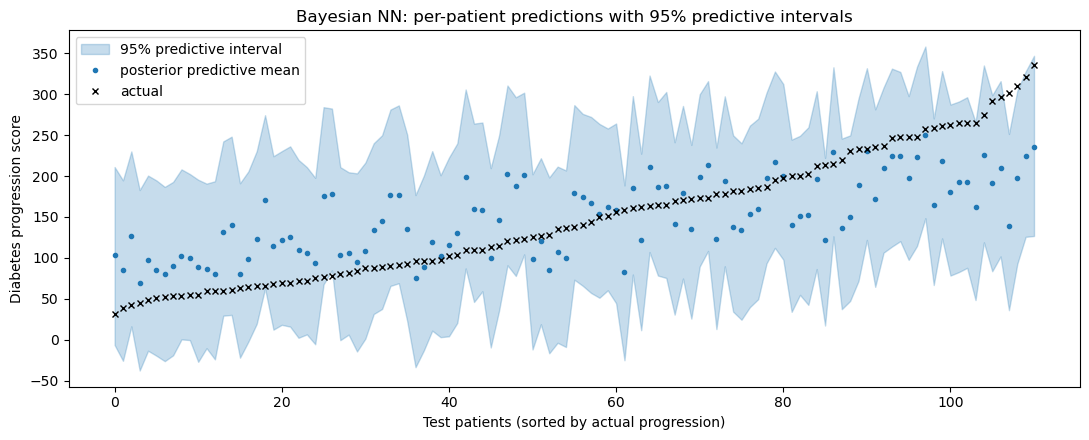

In [29]:
order = np.argsort(y_test_orig)
xs = np.arange(len(y_test_orig))

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.fill_between(xs,
                y_pred_lo95_orig[order],
                y_pred_hi95_orig[order],
                alpha=0.25, color='C0', label='95% predictive interval')
ax.plot(xs, y_pred_mean_orig[order], '.', color='C0', label='posterior predictive mean')
ax.plot(xs, y_test_orig[order], 'x', color='black', markersize=4, label='actual')
ax.set_xlabel('Test patients (sorted by actual progression)')
ax.set_ylabel('Diabetes progression score')
ax.set_title('Bayesian NN: per-patient predictions with 95% predictive intervals')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Learning $\sigma$ and $\tau$ from the data: a fully Bayesian extension

In the analysis above, we learned reasonable values of $\sigma$ and $\tau$ from the frequentist solution based on least squares minimization with weight decay. Specifically, we have *fixed* $\sigma \approx 0.7$ (using the SGD residual std) and $\tau \approx 0.12$ (chosen to match the weight-decay parameter). However both $\sigma$ and $\tau$ are unknown features of the data-generating process and should themselves be inferred. This can be done in the Bayesian framework using priors on $\sigma$ and $\tau$:

\begin{align*}
   y_i \mid \theta, \sigma^2 &\sim N(f_\theta(x_i), \sigma^2) \\
   \theta_j \mid \tau^2 &\sim N(0, \tau^2) \quad \text{(independent)} \\
   \sigma^2 &\sim \mathrm{InverseGamma}(a_\sigma, b_\sigma) \\
   \tau^2 &\sim \mathrm{InverseGamma}(a_\tau, b_\tau)
\end{align*}

We used standard Inverse Gamma priors for $\sigma^2$ and $\tau^2$. For the hyperparameters $a_{\sigma}$ and $b_{\sigma}$, we will use the standard choices $0.001$ and $0.001$ (recall that with these choices, the IG prior on $\sigma^2$ is almost the same as assuming that $\log \sigma$ is uniform on $(-\infty, \infty)$). 

### How to do Bayesian inference in this full model?

Can HMC be directly used to simulate from the posterior of $\theta, \sigma, \tau$? HMC requires a continuous, unconstrained, differentiable log posterior. Because $\sigma, \tau > 0$, we reparameterize $s = \log\sigma, t = \log\tau$, add the change-of-variables Jacobian terms (i.e. $+s$ and $+t$ to the log-density), and run HMC over the joint vector. This works in principle, but $\sigma$ and $\tau$ live on a wildly different scale than the 661 weights and biases — a single step size $\epsilon$ mixes poorly unless we use a non-trivial mass matrix (i.e., unless we change the kinetic energy to include a positive definite matrix). This is doable, but a hassle to tune well.

A simpler alternative approach is to use the HMC only for $\theta$ within a Gibbs sampler which updates $\sigma$ and $\tau$. Note that, given $\theta$, the conditional posteriors of $\sigma$ and $\tau$ can be written as: 
\begin{align*}
   \sigma^2 \mid \theta, \text{data} &\sim \mathrm{InvGamma}\!\left(a_\sigma + \tfrac{n}{2},\; b_\sigma + \tfrac{1}{2}\sum_i (y_i - f_\theta(x_i))^2\right) \\
   \tau^2 \mid \theta &\sim \mathrm{InvGamma}\!\left(a_\tau + \tfrac{D}{2},\; b_\tau + \tfrac{1}{2}\|\theta\|^2\right)
\end{align*}
This is the algorithm that we shall use. Each MCMC iteration is given by: 
1. **HMC step** for $\theta$ holding $(\sigma, \tau)$ fixed — exactly the HMC code we already have.
2. **Gibbs step** drawing $\sigma^2$ from its conditional InverseGamma.
3. **Gibbs step** drawing $\tau^2$ from its conditional InverseGamma.

This composite kernel still has the joint posterior as its stationary distribution, and avoids tuning HMC jointly for $\sigma, \tau$. 

Below we re-define the potential-energy and HMC-step functions to take $\sigma$ and $\tau$ as explicit arguments, rather than reading them from globals. That is the only change to the HMC code itself.

In [39]:
def potential_energy_st(theta, sigma, tau):
    """U(theta) = neg log conditional posterior of theta given sigma, tau."""
    pred = bnn_forward(theta, X_train_t, layer_sizes)
    resid = y_train_t - pred
    neg_log_lik   = 0.5 * torch.sum(resid ** 2) / sigma**2
    neg_log_prior = 0.5 * torch.sum(theta ** 2) / tau**2
    return neg_log_lik + neg_log_prior


def U_and_grad_st(theta, sigma, tau):
    theta = theta.detach().clone().requires_grad_(True)
    U = potential_energy_st(theta, sigma, tau)
    grad = torch.autograd.grad(U, theta)[0]
    return U.detach(), grad.detach()


def hmc_step_st(theta, sigma, tau, epsilon, L):
    theta_current = theta.detach().clone()
    v_current = torch.randn_like(theta_current)
    current_U, current_grad = U_and_grad_st(theta_current, sigma, tau)
    current_K = 0.5 * torch.sum(v_current ** 2)

    theta_new = theta_current.clone()
    v_new = v_current.clone()
    v_new = v_new - 0.5 * epsilon * current_grad
    for j in range(L):
        theta_new = theta_new + epsilon * v_new
        U_new, grad_new = U_and_grad_st(theta_new, sigma, tau)
        if j != L - 1:
            v_new = v_new - epsilon * grad_new
    v_new = v_new - 0.5 * epsilon * grad_new
    v_new = -v_new
    proposed_U = U_new
    proposed_K = 0.5 * torch.sum(v_new ** 2)
    log_accept = current_U + current_K - proposed_U - proposed_K
    if torch.log(torch.rand(())) < log_accept:
        return theta_new.detach(), True
    else:
        return theta_current.detach(), False


### Main Gibbs-HMC loop

Each iteration: HMC step on $\theta$, then exact draws of $\sigma^2$ and $\tau^2$ from their InverseGamma conditional posteriors.

If $X \sim \mathrm{Gamma}(\text{shape}=a, \text{rate}=b)$ then $1/X \sim \mathrm{InvGamma}(a, b)$. NumPy's `np.random.gamma` uses scale (= 1/rate), so we pass `scale=1/b`.

Below we take the number of samples to be larger (4000) so we can see if the Gibbs sampler iterates for $\sigma$ and $\tau$ display good mixing. 

In [40]:
# Hyperpriors (noninformative)
a_sigma_prior, b_sigma_prior = 0.001, 0.001
a_tau_prior,   b_tau_prior   = 0.001, 0.001

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Initialization (deliberately not the SGD values, to confirm the chain finds them on its own)
theta_h = 0.1 * torch.randn(D)
sigma_h = 1.0
tau_h   = 0.5

n_train = X_train_t.shape[0]
n_samples_h = 4000
epsilon_h, L_h = 0.02, 100

theta_samples_h = []
sigma_samples_h = np.zeros(n_samples_h)
tau_samples_h   = np.zeros(n_samples_h)
accepts_h = []

for it in range(n_samples_h):
    # 1. HMC update for theta given current sigma, tau
    theta_h, accepted = hmc_step_st(theta_h, sigma_h, tau_h, epsilon_h, L_h)
    accepts_h.append(accepted)

    # 2. Gibbs update for sigma^2 | theta, y  ~  InvGamma(a + n/2, b + RSS/2)
    with torch.no_grad():
        pred = bnn_forward(theta_h, X_train_t, layer_sizes)
        rss = torch.sum((y_train_t - pred) ** 2).item()
    a_post = a_sigma_prior + n_train / 2
    b_post = b_sigma_prior + 0.5 * rss
    sigma_h = math.sqrt(1.0 / np.random.gamma(shape=a_post, scale=1.0 / b_post))

    # 3. Gibbs update for tau^2 | theta  ~  InvGamma(a + D/2, b + ||theta||^2/2)
    a_post_t = a_tau_prior + D / 2
    b_post_t = b_tau_prior + 0.5 * torch.sum(theta_h ** 2).item()
    tau_h = math.sqrt(1.0 / np.random.gamma(shape=a_post_t, scale=1.0 / b_post_t))

    # Store
    theta_samples_h.append(theta_h.clone())
    sigma_samples_h[it] = sigma_h
    tau_samples_h[it]   = tau_h

    if (it + 1) % 100 == 0:
        recent_acc = np.mean(accepts_h[-100:])
        print(
            f"iter {it+1:4d}/{n_samples_h}  "
            f"acc={recent_acc:.2f}  "
            f"sigma={sigma_h:.3f}  tau={tau_h:.3f}"
        )

theta_samples_h = torch.stack(theta_samples_h)
print(f"\nFinal HMC acceptance rate: {np.mean(accepts_h):.3f}")


iter  100/4000  acc=0.85  sigma=0.682  tau=0.264
iter  200/4000  acc=0.81  sigma=0.684  tau=0.239
iter  300/4000  acc=0.80  sigma=0.685  tau=0.208
iter  400/4000  acc=0.82  sigma=0.695  tau=0.287
iter  500/4000  acc=0.92  sigma=0.711  tau=0.256
iter  600/4000  acc=0.85  sigma=0.694  tau=0.291
iter  700/4000  acc=0.77  sigma=0.650  tau=0.306
iter  800/4000  acc=0.78  sigma=0.657  tau=0.291
iter  900/4000  acc=0.80  sigma=0.618  tau=0.276
iter 1000/4000  acc=0.82  sigma=0.675  tau=0.273
iter 1100/4000  acc=0.79  sigma=0.648  tau=0.269
iter 1200/4000  acc=0.81  sigma=0.683  tau=0.264
iter 1300/4000  acc=0.83  sigma=0.701  tau=0.328
iter 1400/4000  acc=0.84  sigma=0.648  tau=0.343
iter 1500/4000  acc=0.68  sigma=0.677  tau=0.348
iter 1600/4000  acc=0.76  sigma=0.676  tau=0.275
iter 1700/4000  acc=0.86  sigma=0.721  tau=0.318
iter 1800/4000  acc=0.70  sigma=0.623  tau=0.317
iter 1900/4000  acc=0.85  sigma=0.682  tau=0.302
iter 2000/4000  acc=0.75  sigma=0.708  tau=0.292
iter 2100/4000  acc=

### Diagnostics: did $\sigma$ and $\tau$ converge?

The following trace plots show whether the chain has stabilized; histograms (after burn-in) show the marginal posteriors of $\sigma$ and $\tau$. The dashed vertical lines mark the values used in the original *fixed*-$(\sigma, \tau)$ run.

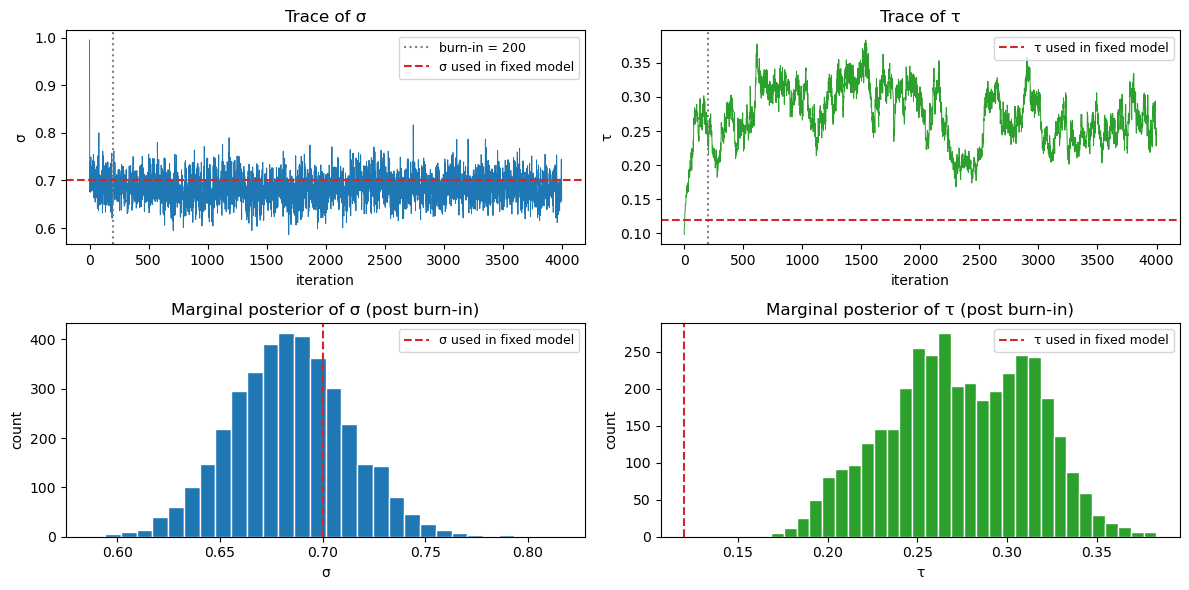

Posterior mean of σ: 0.684  (95% CI: [0.628, 0.741])
Posterior mean of τ: 0.274  (95% CI: [0.197, 0.345])


In [41]:
burn_in = 200

fig, axes = plt.subplots(2, 2, figsize=(12, 6))

axes[0,0].plot(sigma_samples_h, color='C0', lw=0.7)
axes[0,0].axvline(burn_in, color='gray', linestyle=':', label=f'burn-in = {burn_in}')
axes[0,0].axhline(0.7, color='C3', linestyle='--', label='σ used in fixed model')
axes[0,0].set_xlabel('iteration'); axes[0,0].set_ylabel('σ')
axes[0,0].set_title('Trace of σ'); axes[0,0].legend(loc='upper right', fontsize=9)

axes[0,1].plot(tau_samples_h, color='C2', lw=0.7)
axes[0,1].axvline(burn_in, color='gray', linestyle=':')
axes[0,1].axhline(0.12, color='C3', linestyle='--', label='τ used in fixed model')
axes[0,1].set_xlabel('iteration'); axes[0,1].set_ylabel('τ')
axes[0,1].set_title('Trace of τ'); axes[0,1].legend(loc='upper right', fontsize=9)

axes[1,0].hist(sigma_samples_h[burn_in:], bins=30, color='C0', edgecolor='white')
axes[1,0].axvline(0.7, color='C3', linestyle='--', label='σ used in fixed model')
axes[1,0].set_xlabel('σ'); axes[1,0].set_ylabel('count')
axes[1,0].set_title('Marginal posterior of σ (post burn-in)'); axes[1,0].legend(fontsize=9)

axes[1,1].hist(tau_samples_h[burn_in:], bins=30, color='C2', edgecolor='white')
axes[1,1].axvline(0.12, color='C3', linestyle='--', label='τ used in fixed model')
axes[1,1].set_xlabel('τ'); axes[1,1].set_ylabel('count')
axes[1,1].set_title('Marginal posterior of τ (post burn-in)'); axes[1,1].legend(fontsize=9)

plt.tight_layout(); plt.show()

print(f"Posterior mean of σ: {sigma_samples_h[burn_in:].mean():.3f}  "
      f"(95% CI: [{np.quantile(sigma_samples_h[burn_in:], 0.025):.3f}, "
      f"{np.quantile(sigma_samples_h[burn_in:], 0.975):.3f}])")
print(f"Posterior mean of τ: {tau_samples_h[burn_in:].mean():.3f}  "
      f"(95% CI: [{np.quantile(tau_samples_h[burn_in:], 0.025):.3f}, "
      f"{np.quantile(tau_samples_h[burn_in:], 0.975):.3f}])")


The marginal posteriors give us *uncertainty quantification on the noise level and the regularization strength* — quantities the original model treated as free hyperparameters. Two observations from this run:

- **$\sigma$ is well-pinned-down**: the posterior mean ($\approx 0.68$) sits very close to the SGD-derived value, with a tight 95% credible interval. The original choice of $\sigma$ was well-calibrated. The $\sigma$ iterates given by the Gibbs chain show good mixing. 
- **$\tau$ is much larger than expected**: the posterior mean for $\tau$ is 0.274 which is much larger than the value of $0.12$ that we used based on the SGD solution. However the chain does not seem to mix well. So repeated runs will give different answers for $\tau$. Getting good mixing for $\tau$ is difficult in such hierarchical models (see the paper "Hamiltonian Monte Carlo for Hierarchical Models" by Betancourt and Girolami (2013) for some ideas on getting chains with good mixing properties for $\tau$). 

### Test-set predictions under the hierarchical model

We form posterior predictive draws $y_*^{(s)} \sim N(f_{\theta^{(s)}}(x_*), \sigma_s^2)$ — using each iteration's *own* sampled $\sigma_s$ — so the predictive distribution properly accounts for noise-level uncertainty as well. Then we compare to the previous version where we fixed-$(\sigma,\tau)$ values (derived from SGD).

In [43]:
# Use post-burn-in samples
post_idx = slice(burn_in, n_samples_h)
theta_post = theta_samples_h[post_idx]
sigma_post = sigma_samples_h[post_idx]
tau_post   = tau_samples_h[post_idx]
S_h = theta_post.shape[0]

with torch.no_grad():
    f_preds_h = torch.stack([bnn_forward(s, X_test_t, layer_sizes) for s in theta_post]).squeeze(-1)
# f_preds_h shape: (S, n_test)

sigma_post_t = torch.tensor(sigma_post, dtype=torch.float32).unsqueeze(1)  # (S, 1)
y_pred_h = f_preds_h + sigma_post_t * torch.randn_like(f_preds_h)

y_test_flat = y_test_t.squeeze()
lo95_h = torch.quantile(y_pred_h, 0.025, dim=0)
hi95_h = torch.quantile(y_pred_h, 0.975, dim=0)
cov95_h = ((y_test_flat >= lo95_h) & (y_test_flat <= hi95_h)).float().mean().item()
rmse_std_h  = torch.sqrt(torch.mean((f_preds_h.mean(dim=0) - y_test_flat)**2)).item()
rmse_orig_h = rmse_std_h * y_std

print("Hierarchical (sigma, tau learned) BNN:")
print(f"  Test RMSE (standardized):    {rmse_std_h:.4f}")
print(f"  Test RMSE (original):        {rmse_orig_h:.2f}")
print(f"  Empirical 95% coverage:      {cov95_h:.3f}")

print(f"\nFor reference (fixed sigma=0.7, tau=0.12):")
print(f"  Test RMSE (standardized):    {hmc_rmse_standardized:.4f}")
print(f"  Test RMSE (original):        {hmc_rmse_original:.2f}")
print(f"  Empirical 95% coverage:      {covered95:.3f}")


Hierarchical (sigma, tau learned) BNN:
  Test RMSE (standardized):    0.6996
  Test RMSE (original):        53.83
  Empirical 95% coverage:      0.964

For reference (fixed sigma=0.7, tau=0.12):
  Test RMSE (standardized):    0.7176
  Test RMSE (original):        55.21
  Empirical 95% coverage:      0.973


The hierarchical model analysis gives a slightly better test error (of 53.83). 

By placing inverse-gamma priors on $\sigma^2$ and $\tau^2$, we removed the two ad-hoc hyperparameters of the original model and now infer them along with the network weights. The MCMC machinery extends very naturally:

- **Plain HMC alone can still do it** — with reparameterization to log-scale and a Jacobian term in the log-posterior — but it has to be carefully tuned because $\sigma, \tau$ live on a different scale than $\theta$.
- **Gibbs-within-HMC is the right tool here**, because the conjugate inverse-gamma priors give closed-form conditional posteriors for $\sigma^2$ and $\tau^2$. We pay essentially zero extra cost per iteration and avoid additional HMC tuning.

For more advice on using Hamiltonian Monte Carlo for such hierarchical mixture models, see Subsection 4.5 of the Neal (2011) paper titled "MCMC using Hamiltonian Dynamics". 